<a href="https://colab.research.google.com/github/Mitch-Cruz/03MAIR-Algoritmos-de-Optimizacion/blob/main/AG2/Practica_Individual_AG2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Práctica Individual - AG2

Algoritmos de Optimización

Reinaldo Mitchell Cruz Barrios

https:https://drive.google.com/file/d/1cS1INNWyHU7gOIzXSzMXrCptgpZ77CRD/view?usp=sharing (Cuaderno)

https://github.com/Mitch-Cruz/03MAIR-Algoritmos-de-Optimizacion/tree/main/AG2 (GitHub)

## **Ramificación y Poda. Practica.**

In [ ]:
# Ramificación y Poda. Practica
# Algoritmos (Fuerza Bruta y Ramificación y Poda).
# - Generar matrices con valores aleatorios de mayores dimensiones (5,6,7,…) y ejecutar ambos algoritmos.
# - ¿A partir de que dimensión el algoritmo por fuerza bruta deja de ser una opción?
# - ¿Hay algún valor de la dimensión a partir de la cual el algoritmo de ramificación y poda también deja de ser una opción válida?

In [ ]:
# Generación de matrices de costes.
import random

def generar_matriz_costes(n, low=1, high=99, seed=None):
    """Genera una matriz n×n de costes enteros aleatorios.

    Parámetros
    ---------
    n : int
        Dimensión de la matriz.
    low, high : int
        Rango [low, high] de los costes.
    seed : int | None
        Semilla para reproducibilidad.

    Devuelve
    --------
    list[list[int]]
        Matriz COSTES[a][t].
    """
    if seed is not None:
        random.seed(seed)
    return [[random.randint(low, high) for _ in range(n)] for _ in range(n)]

def imprimir_matriz(M):
    """Imprime una matriz por filas."""
    for fila in M:
        print(fila)

# Ejemplo...
C = generar_matriz_costes(4, seed=7)
imprimir_matriz(C)

[42, 20, 51, 84]
[7, 10, 69, 13]
[47, 75, 8, 65]
[28, 5, 12, 56]


In [ ]:
# Función de coste.
def coste(S, COSTES):
    """Coste total de una solución (completa o parcial).

    Convención:
      - S[t] = agente asignado a la tarea t
      - COSTES[a][t] = coste de asignar agente a la tarea t
    """
    return sum(COSTES[S[t]][t] for t in range(len(S)))

def es_valida(S):
    """Una solución parcial es válida si no repite agentes."""
    return len(set(S)) == len(S)

# Prueba...
C = generar_matriz_costes(4, seed=7)
S_ok = (0, 1, 2, 3)
S_bad = (0, 1, 1)

print("Coste S_ok:", coste(S_ok, C), "| válida:", es_valida(S_ok))
print("S_bad válida:", es_valida(S_bad))

Coste S_ok: 116 | válida: True
S_bad válida: False


## **Algoritmo 1 - Fuerza bruta.**

In [ ]:
# Algoritmo 1 - Fuerza bruta.
import itertools

def fuerza_bruta_asignacion(COSTES):
    """Resuelve asignación por fuerza bruta.

    Devuelve
    --------
    best_S : tuple[int]
        Mejor asignación (S[t]=agente).
    best_cost : int
        Coste mínimo.
    evaluadas : int
        Número de soluciones completas evaluadas (≈ n!).
    """
    n = len(COSTES)
    best_S = None
    best_cost = float("inf")
    evaluadas = 0

    for S in itertools.permutations(range(n)):
        evaluadas += 1
        c = coste(S, COSTES)
        if c < best_cost:
            best_cost = c
            best_S = S

    return best_S, best_cost, evaluadas

# Prueba...
C = generar_matriz_costes(4, seed=1)
sol, val, evals = fuerza_bruta_asignacion(C)
print("sol:", sol)
print("coste:", val)
print("evaluadas:", evals)

sol: (0, 1, 2, 3)
coste: 122
evaluadas: 24


## **Algoritmo 2 - Ramificación y Poda.**

In [ ]:
# Algoritmo 2 - Ramificación y Poda.
def cota_inferior_LB(S, COSTES):
    """Cota inferior (Lower Bound) para una solución parcial S.

    - S[t] = agente asignado a la tarea t, para t en [0, len(S)-1]
    - Para tareas restantes, suma mínimos por columna usando agentes disponibles.

    Nota: la parte estimada es relajada (cota válida, pero menos ajustada).
    """
    n = len(COSTES)
    usados = set(S)

    # 1) coste real de lo asignado.
    total = coste(S, COSTES)

    # 2) estimación optimista para tareas restantes.
    for t in range(len(S), n):
        total += min(COSTES[a][t] for a in range(n) if a not in usados)

    return total

def branch_and_bound_asignacion(COSTES):
    """Ramificación y Poda (Branch and Bound) (minimización) para el problema de asignación.

    Devuelve
    --------
    best_S : tuple[int]
        Mejor asignación encontrada (óptima).
    best_cost : int
        Coste mínimo.
    stats : dict
        Estadísticas: nodos generados/expandidos, podas, iteraciones.
    """
    n = len(COSTES)

    # Caso simple: Inicial (solución rápida): (0,1,2,...).
    best_S = tuple(range(n))
    best_cost = coste(best_S, COSTES)

    # Frontera: Lista de (solución_parcial S, cota_inferior LB).
    frontera = [((), cota_inferior_LB((), COSTES))]

    nodos_generados = 1
    nodos_expandidos = 0
    podas = 0
    iteraciones = 0

    while frontera:
        iteraciones += 1

        # Selección: Expandir el nodo con menor LB (best-first).
        frontera.sort(key=lambda x: x[1])
        S, LB = frontera.pop(0)

        # Poda: Si LB ya no puede mejorar best_cost, cortamos.
        if LB >= best_cost:
            podas += 1
            continue

        # Si es solución completa, actualizamos caso simple.
        if len(S) == n:
            c = coste(S, COSTES)
            if c < best_cost:
                best_cost = c
                best_S = S
            continue

        # Ramificación: Asignar la siguiente tarea t.
        nodos_expandidos += 1
        t = len(S)  # índice de la siguiente tarea a asignar
        usados = set(S)

        for a in range(n):
            if a in usados:
                continue
            hijo = S + (a,)
            lb_hijo = cota_inferior_LB(hijo, COSTES)
            nodos_generados += 1

            # Poda del hijo.
            if lb_hijo >= best_cost:
                podas += 1
                continue

            frontera.append((hijo, lb_hijo))

    stats = {
        "iteraciones": iteraciones,
        "nodos_generados": nodos_generados,
        "nodos_expandidos": nodos_expandidos,
        "podas": podas,
    }
    return best_S, best_cost, stats


# Verificación con fuerza bruta en un caso pequeño.
C = generar_matriz_costes(6, seed=2)

sol_fb, cost_fb, evals_fb = fuerza_bruta_asignacion(C)
sol_bb, cost_bb, stats_bb = branch_and_bound_asignacion(C)

print("FB:", cost_fb, sol_fb, "| evaluadas:", evals_fb)
print("BB:", cost_bb, sol_bb, "| stats:", stats_bb)

assert cost_fb == cost_bb, "Branch & Bound debe encontrar el óptimo (mismo coste que fuerza bruta)"

FB: 133 (2, 0, 1, 4, 5, 3) | evaluadas: 720
BB: 133 (2, 0, 1, 4, 5, 3) | stats: {'iteraciones': 31, 'nodos_generados': 31, 'nodos_expandidos': 8, 'podas': 22}


## **Comparación de escalabilidad (para n = 5, 6, 7, …).**

In [ ]:
# Comparación de escalabilidad (para n = 5, 6, 7, …).

"""
Para evitar que el notebook se quede colgado, fijamos un umbral:

- Si la fuerza bruta tarda más de TIEMPO_MAX, la marcamos como no viable.

"""
import time
import pandas as pd

TIEMPO_MAX = 2.0  # segundos (ajustable)

def medir(func, COSTES):
    """Ejecuta func(COSTES) y devuelve (salida, tiempo en segundos)."""
    t0 = time.perf_counter()
    out = func(COSTES)
    t1 = time.perf_counter()
    return out, (t1 - t0)

def experimento(n_values, low=1, high=99, seed_base=123):
    """Corre el experimento para varias dimensiones n y devuelve un DataFrame."""
    filas = []

    for n in n_values:
        C = generar_matriz_costes(n, low=low, high=high, seed=seed_base + n)

        # Ramificación y Poda.
        (sol_bb, cost_bb, stats_bb), t_bb = medir(branch_and_bound_asignacion, C)

        # Fuerza bruta (con limite práctico).
        sol_fb = cost_fb = evals_fb = None
        t_fb = float("inf")

        # Ejecutamos fuerza bruta solo hasta cierto n (por seguridad).
        # Pero, si supera TIEMPO_MAX, la marcamos como inf (pista del profesor en otro ejercicio).
        if n <= 11:
            t0 = time.perf_counter()
            sol_fb, cost_fb, evals_fb = fuerza_bruta_asignacion(C)
            t_fb = time.perf_counter() - t0
            if t_fb > TIEMPO_MAX:
                t_fb = float("inf") # pista del profesor en otro ejercicio.

        filas.append({
            "n": n,
            "BB_tiempo_s": t_bb,
            "BB_coste": cost_bb,
            "BB_iteraciones": stats_bb["iteraciones"],
            "BB_nodos_generados": stats_bb["nodos_generados"],
            "BB_nodos_expandidos": stats_bb["nodos_expandidos"],
            "BB_podas": stats_bb["podas"],
            "FB_tiempo_s": t_fb,
            "FB_evaluadas": evals_fb,
            "FB_coste": cost_fb,
        })

    return pd.DataFrame(filas)

df = experimento(range(5, 13))
print ("Nota: Los datos se diferencian por los prefijos BB y FB. BB para Ramificación y Poda (Branch and Bound) y FB para Fuerza Bruta.")
print() # empty line.
df

Nota: Los datos se diferencian por los prefijos BB y FB. BB para Ramificación y Poda (Branch and Bound) y FB para Fuerza Bruta.



,n,BB_tiempo_s,BB_coste,BB_iteraciones,BB_nodos_generados,BB_nodos_expandidos,BB_podas,FB_tiempo_s,FB_evaluadas,FB_coste
0,5,0.000139,84,19,23,7,15,0.000117,120.0,84.0
1,6,0.000351,106,48,48,13,34,0.000697,720.0,106.0
2,7,0.000806,117,103,103,24,78,0.005779,5040.0,117.0
3,8,0.000699,126,61,61,12,48,0.051774,40320.0,126.0
4,9,0.016165,136,634,634,126,507,0.442556,362880.0,136.0
5,10,0.280907,172,2951,2951,533,2417,inf,3628800.0,172.0
6,11,0.059026,160,1321,1321,184,1136,inf,39916800.0,160.0
7,12,0.098953,157,1191,1191,176,1014,inf,NaN,NaN


##**¿A partir de qué dimensión deja de ser viable cada método?**
> El primer tiempo con valor **inf** (que supera TIEMPO_MAX) en el DataFrame, denota la primera n no viable.

In [ ]:
def primera_no_viable(df, prefijo):
    """Devuelve la primera dimensión n donde el método deja de ser viable."""
    name = prefijo + '_tiempo_s'
    sub = df[df[name] == float("inf")]

    if sub.empty:
        return None

    return int(sub.iloc[0]["n"])

n_fb = primera_no_viable(df, 'FB') # Fuerza Bruta
n_bb = primera_no_viable(df, 'BB') # Ramificación y Poda

print("Primera n no viable (Fuerza Bruta):", n_fb)
print("Primera n no viable (Ramificación y Poda):", n_bb)

Primera n no viable (Fuerza Bruta): 10
Primera n no viable (Ramificación y Poda): None


## **Visualización de tiempos.**

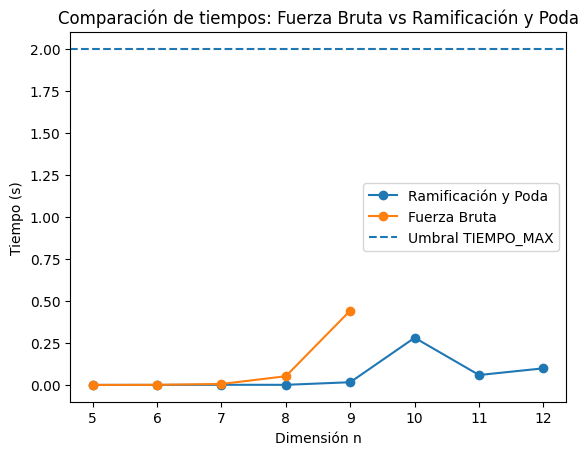

In [ ]:
import matplotlib.pyplot as plt
import math

plt.figure()
plt.plot(df["n"], df["BB_tiempo_s"], marker="o", label="Ramificación y Poda")

# Para fuerza bruta, omitimos los 'inf' usando NaN (para que el plot no explote).
fb_times = [t if t != float("inf") else float("nan") for t in df["FB_tiempo_s"]]
plt.plot(df["n"], fb_times, marker="o", label="Fuerza Bruta")

plt.axhline(TIEMPO_MAX, linestyle="--", label="Umbral TIEMPO_MAX")
plt.xlabel("Dimensión n")
plt.ylabel("Tiempo (s)")
plt.title("Comparación de tiempos: Fuerza Bruta vs Ramificación y Poda")
plt.legend()
plt.show()

## **Conclusiones.**

1) **La Fuerza Bruta** crece como n! evaluando todas las soluciones en el espacio de búsqueda, por eso deja de ser viable muy pronto.  
2) **La Ramificación y Poda** en teoría crece como n! pero en la practica escala más, su efectividad depende de la calidad de la cota inferior.
> La Ramificación y Poda no mejora la complejidad asintótica n! del peor caso.
Pero en la practica mejora el número real de casos que hay que explorar (reduce sustancialmente el espacio de búsqueda). Mejora el caso medio y el caso práctico, no el peor caso teórico.
> Para que la Ramificación y Poda aguante dimensiones mayores, hay que mejorar la cota (por ejemplo, usando el ***método húngaro***).

***Método húngaro***:
Algoritmo polinómico O(n^3) que resuelve el problema de asignación óptima transformando la matriz de costes mediante reducciones por filas y columnas y determinando un conjunto mínimo de líneas que interceptan los ceros, hasta obtener una asignación de coste mínimo global.

## Referencias

> **Wikipedia:** Fuerza Bruta:
https://es.wikipedia.org/wiki/B%C3%BAsqueda_de_fuerza_bruta

> **Wikipedia:** Ramificación y poda (Branch and Bound):
https://es.wikipedia.org/wiki/Ramificación_y_poda

> **Wikipedia:** Problema de asignación:
https://es.wikipedia.org/wiki/Problema_de_asignaci%C3%B3n

> **Wikipedia:** Algoritmo húngaro:
https://es.wikipedia.org/wiki/Algoritmo_h%C3%BAngaro

> **Book:** Cormen, T. H., Leiserson, C. E., Rivest, R. L., & Stein, C. (2009). Introduction to Algorithms (3rd ed.). MIT Press.


## **Descenso del gradiente. Práctica.**

In [ ]:
# Descenso del gradiente. Práctica
# - Minimizar la función por descenso del gradiente.

**¿Te atreves a optimizar la función?:**

$$f(x)=sin(1/2 * x^2 - 1/4 * y^2 + 3) * cos(2*x + 1 - e^y)$$
<br>
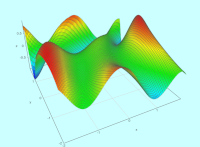


In [ ]:
import numpy as np
import sympy as sp
from sympy.plotting import plot3d
import matplotlib.pyplot as plt
import random

In [ ]:
# Definimos la la función objetivo (pista del profesor).
f= lambda X: math.sin(1/2 * X[0]**2 - 1/4 * X[1]**2 + 3) *math.cos(2*X[0] + 1 - math.exp(X[1]) )

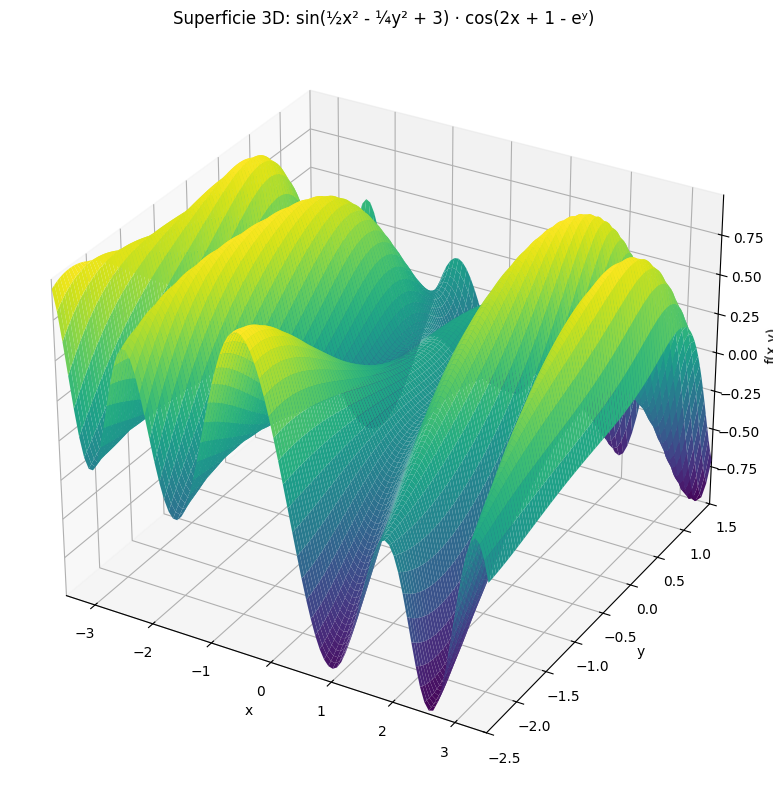

In [ ]:
# Visualización 3D simbólica de la función objetivo...

x, y = sp.symbols('x y')

# Definimos la misma función objetivo en sympy.
expr = sp.sin( sp.Rational(1,2)*x**2 - sp.Rational(1,4)*y**2 + 3 ) * \
        sp.cos( 2*x + 1 - sp.exp(y) )

# Rango.
plot3d(expr,
        (x, -3.5, 3.5),
        (y, -2.5, 1.5),
        title="Superficie 3D: sin(½x² - ¼y² + 3) · cos(2x + 1 - eʸ)",
        size=(11, 8),
        xlabel='x', ylabel='y', zlabel='f(x,y)',
        grid=True,
        show=True)

In [ ]:
# Aproximamos el valor del gradiente en un punto por su definición (pista del profesor).
def df(PUNTO):
    h = 0.01 # paso de perturbación
    T = np.copy(PUNTO) # copia para no modificar el original
    grad = np.zeros(2) # vector gradiente [df/dx, df/dy]
    for it, th in enumerate(PUNTO):
        T[it] = T[it] + h # perturbamos
        grad[it] = (f(T) - f(PUNTO))/h
    return grad

In [ ]:
# Parámetros de visualización.
resolucion = 150   # número de puntos por eje
rango      = 3.5   # rango de x e y: [-rango, rango]

# Malla
X  = np.linspace(-rango, rango, resolucion)
Y  = np.linspace(-rango, rango, resolucion)
XX, YY = np.meshgrid(X, Y)

# Cálculo vectorizado de la función.
Z = np.sin(0.5 * XX**2 - 0.25 * YY**2 + 3) * \
    np.cos(2 * XX + 1 - np.exp(YY))

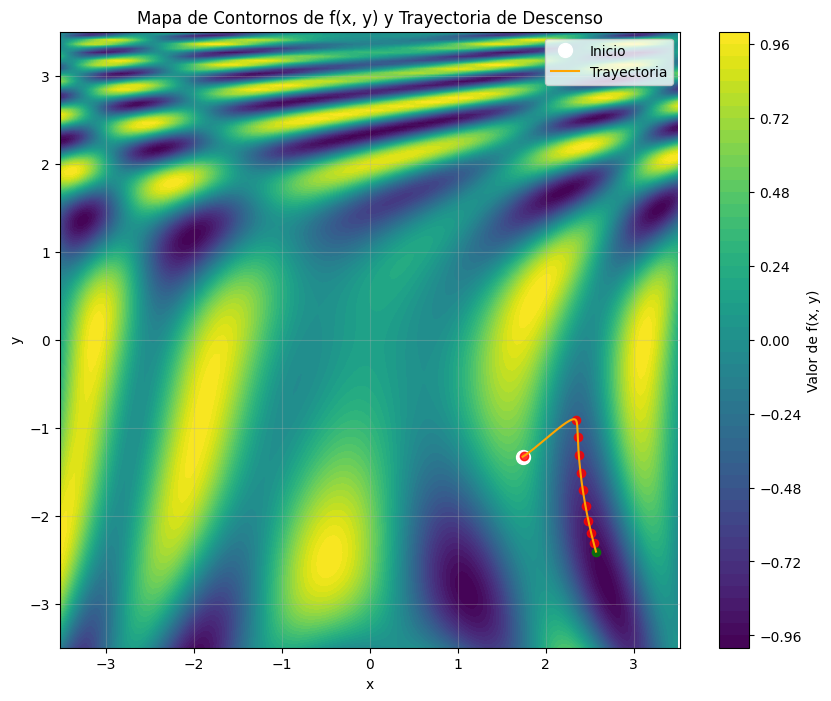

Solución aproximada: [ 2.57041588 -2.40754038]
Valor de f en el punto: -0.9633149708683103


In [ ]:
# Dibujamos el mapa de contornos.
plt.figure(figsize=(10, 8))
plt.contourf(XX, YY, Z, levels=50, cmap='viridis')  # mapa de colores
plt.colorbar(label='Valor de f(x, y)')  # barra de colores
plt.xlabel('x')
plt.ylabel('y')
plt.title('Mapa de Contornos de f(x, y) y Trayectoria de Descenso')

# Punto inicial aleatorio en [-2, 2] (para consistencia con el anterior).
P = np.array([random.uniform(-2, 2), random.uniform(-2, 2)])
plt.plot(P[0], P[1], 'o', c='white', markersize=10, label='Inicio')

# Parámetros del descenso.
TA = 0.01  # tasa de aprendizaje (learning rate)
n_iter = 500  # número de iteraciones
trayectoria = [P.copy()]  # lista para guardar la trayectoria

# Bucle de descenso del gradiente.
for i in range(n_iter):
    grad = df(P)  # calculamos gradiente
    P = P - TA * grad  # actualizamos el punto
    trayectoria.append(P.copy())  # guardamos

    # Pintamos puntos intermedios cada 50 iteraciones para no saturar el gráfico.
    if i % 50 == 0 or i == n_iter - 1:
        color = 'green' if i == n_iter - 1 else 'red'
        plt.plot(P[0], P[1], 'o', c=color, markersize=6, alpha=0.8)

# Dibujamos la trayectoria completa como línea.
tray = np.array(trayectoria)
plt.plot(tray[:, 0], tray[:, 1], '-', c='orange', linewidth=1.5, label='Trayectoria')

plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

# Resultado final...
print('Solución aproximada:', P)
print('Valor de f en el punto:', f(P))

## Referencias
> **Wikipedia:** Gradient descent:
> https://en.wikipedia.org/w/index.php?title=Gradient_descent

> **Book:** Géron, A. (2022). Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow (3rd ed.). O'Reilly.
